N=128 | X_0: 32.0848 | X_1: -26.3375 + -0.0000i


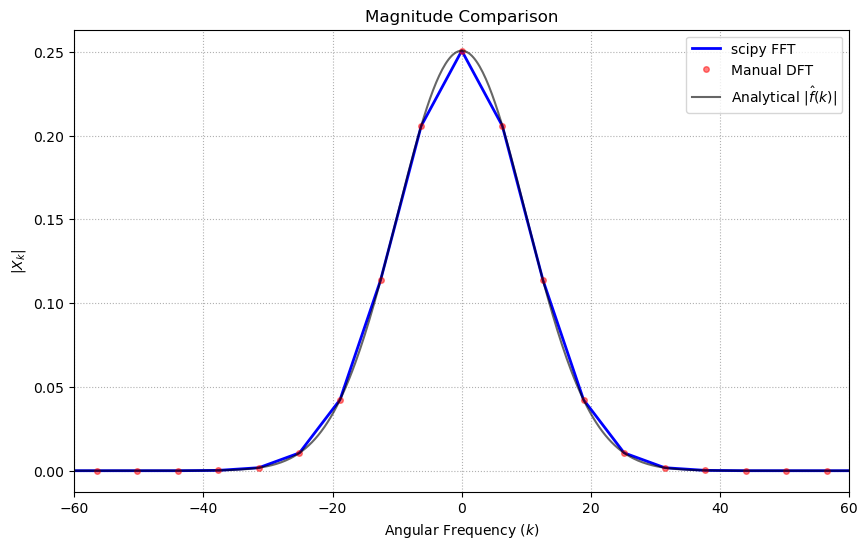

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq

# 1. Setup the function
N = 128
x = np.linspace(0, 1, N, endpoint=False)
xn = np.exp(-50 * (x - 0.5)**2)

# 2. Manual DFT (from Part B)
n_idx = np.arange(N)
k_idx = n_idx.reshape((N, 1))
W = np.exp(-2j * np.pi * k_idx * n_idx / N)
Xk_manual = np.dot(W, xn)

# 3. Off-the-shelf FFT
Xk_fft = fft(xn)
print(f"N={N} | X_0: {Xk_fft[0].real:.4f} | X_1: {Xk_fft[1].real:.4f} + {Xk_fft[1].imag:.4f}i")

# 4. Analytical result from part (a)
k_cont = np.linspace(-60, 60, 500)
analytical = np.sqrt(np.pi / 50) * np.exp(-k_cont**2 / (4 * 50))

# 5. Frequency mapping and shifting for a clean plot
# This moves k=0 to the center of the plot
k_axis = fftshift(fftfreq(N, d=1/N)) * 2 * np.pi
Xk_manual_shifted = fftshift(Xk_manual)
Xk_fft_shifted = fftshift(Xk_fft)

# 5. Create the plot
plt.figure(figsize=(10, 6))

plt.plot(k_axis, np.abs(Xk_fft_shifted)/N, 'b-', lw=2, label='scipy FFT')
plt.plot(k_axis, np.abs(Xk_manual_shifted)/N, 'ro', markersize=4, label='Manual DFT', alpha=0.5)
plt.plot(k_cont, analytical, 'k-', label='Analytical $|\hat{f}(k)|$', alpha=0.6)
plt.title('Magnitude Comparison')
plt.xlabel('Angular Frequency ($k$)')
plt.ylabel('$|X_k|$')
plt.xlim(-60, 60)
plt.legend()
plt.grid(True, ls=':')

plt.show()

Timing Manual DFT...
Timing Scipy FFT...


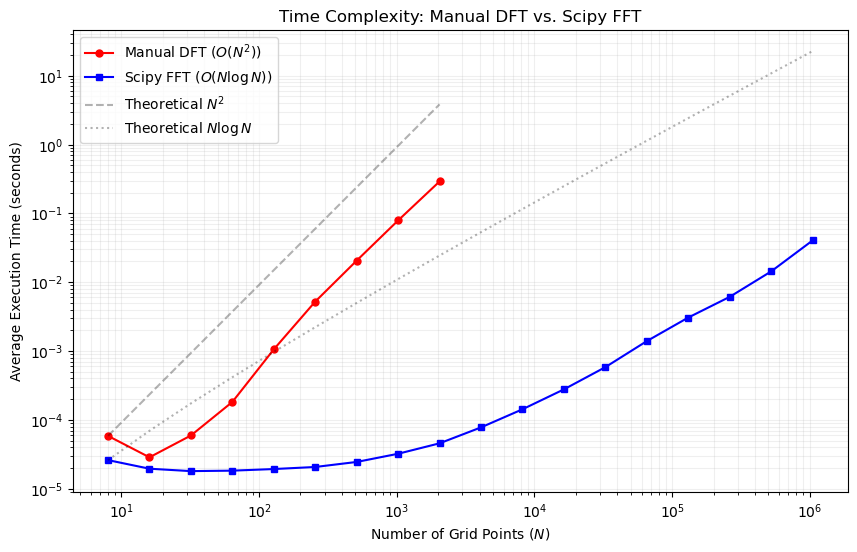

In [5]:
import time
from scipy.fft import fft

# Define the manual DFT as a function for easier timing
def manual_dft(xn):
    N = len(xn)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return np.dot(W, xn)

# Setup parameters
num_averages = 100
j_dft = np.arange(3, 12) # 2^3 to 2^11
j_fft = np.arange(3, 21) # 2^3 to 2^20

dft_times = []
fft_times = []

# Time the Manual DFT
print("Timing Manual DFT...")
for j in j_dft:
    N = 2**j
    x = np.linspace(0, 1, N, endpoint=False)
    xn = np.exp(-50 * (x - 0.5)**2)
    
    start = time.perf_counter()
    for _ in range(num_averages):
        _ = manual_dft(xn)
    end = time.perf_counter()
    dft_times.append((end - start) / num_averages)

# Time the Scipy FFT
print("Timing Scipy FFT...")
for j in j_fft:
    N = 2**j
    x = np.linspace(0, 1, N, endpoint=False)
    xn = np.exp(-50 * (x - 0.5)**2)
    
    start = time.perf_counter()
    for _ in range(num_averages):
        _ = fft(xn)
    end = time.perf_counter()
    fft_times.append((end - start) / num_averages)

plt.figure(figsize=(10, 6))

N_dft = 2**j_dft
N_fft = 2**j_fft

# Plot measured times
plt.loglog(N_dft, dft_times, 'ro-', label='Manual DFT ($O(N^2)$)', markersize=5)
plt.loglog(N_fft, fft_times, 'bs-', label='Scipy FFT ($O(N \log N)$)', markersize=5)

# Add theoretical reference lines to verify scaling
plt.loglog(N_dft, (N_dft**2) * (dft_times[0]/N_dft[0]**2), 'k--', alpha=0.3, label='Theoretical $N^2$')
plt.loglog(N_fft, (N_fft * np.log2(N_fft)) * (fft_times[0]/(N_fft[0]*np.log2(N_fft[0]))), 'k:', alpha=0.3, label='Theoretical $N \log N$')

plt.title('Time Complexity: Manual DFT vs. Scipy FFT')
plt.xlabel('Number of Grid Points ($N$)')
plt.ylabel('Average Execution Time (seconds)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()